#  Laboratorio 9 - ICA's EMG con MNE

Creating RawArray with float64 data, n_channels=8, n_times=180227
    Range : 0 ... 180226 =      0.000 ...   720.904 secs
Ready.
Filtering raw data in 1 contiguous segment
Setting up band-stop filter

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandstop filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower transition bandwidth: 0.50 Hz
- Upper transition bandwidth: 0.50 Hz
- Filter length: 1651 samples (6.604 s)

Filtering raw data in 1 contiguous segment
Setting up band-pass filter from 1 - 40 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 1.00
- Lower transition bandwidth: 1.00 Hz (-6 dB cutoff frequency: 0.50 Hz)
- Upper passband edge: 40.00 Hz
- Uppe

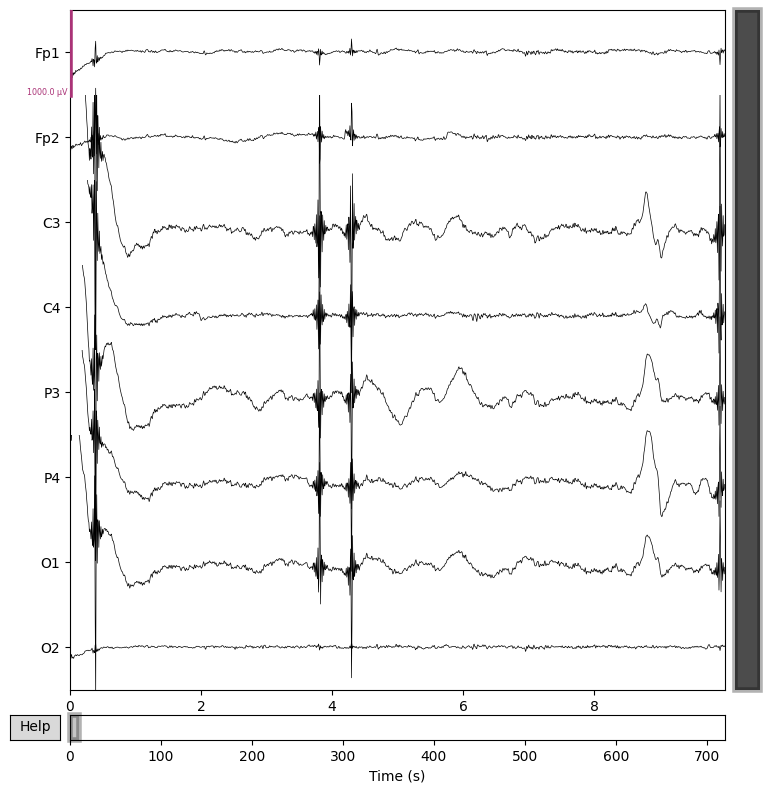

Filtering raw data in 1 contiguous segment
Setting up band-pass filter from 1 - 1e+02 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 1.00
- Lower transition bandwidth: 1.00 Hz (-6 dB cutoff frequency: 0.50 Hz)
- Upper passband edge: 100.00 Hz
- Upper transition bandwidth: 25.00 Hz (-6 dB cutoff frequency: 112.50 Hz)
- Filter length: 825 samples (3.300 s)

Fitting ICA to data using 8 channels (please be patient, this may take a while)
Selecting by number: 7 components
Fitting ICA took 0.8s.


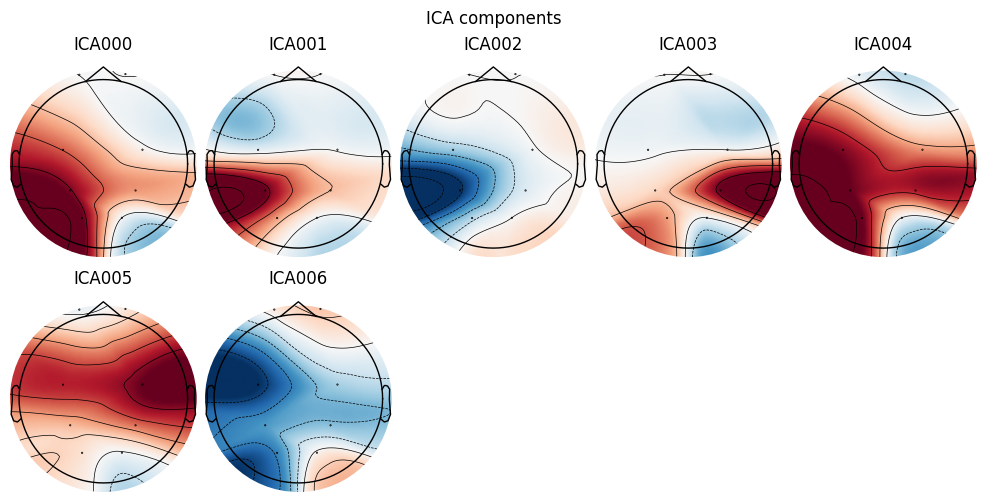

Creating RawArray with float64 data, n_channels=7, n_times=15001
    Range : 250 ... 15250 =      1.000 ...    61.000 secs
Ready.


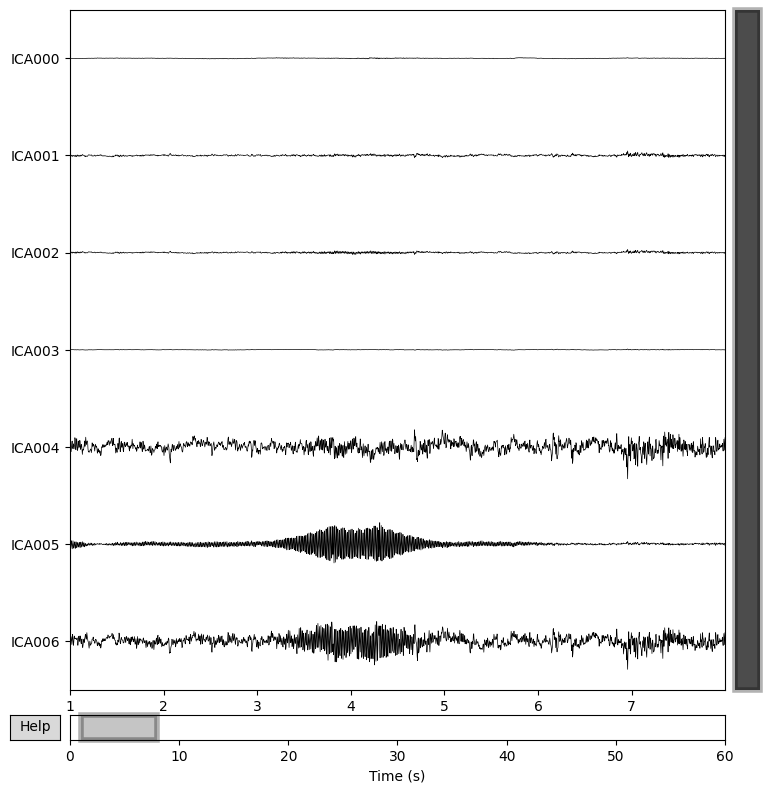

    Using multitaper spectrum estimation with 7 DPSS windows
Not setting metadata
30 matching events found
No baseline correction applied
0 projection items activated
Not setting metadata
30 matching events found
No baseline correction applied
0 projection items activated
Not setting metadata
30 matching events found
No baseline correction applied
0 projection items activated
Not setting metadata
30 matching events found
No baseline correction applied
0 projection items activated
Not setting metadata
30 matching events found
No baseline correction applied
0 projection items activated
Not setting metadata
30 matching events found
No baseline correction applied
0 projection items activated
Not setting metadata
30 matching events found
No baseline correction applied
0 projection items activated


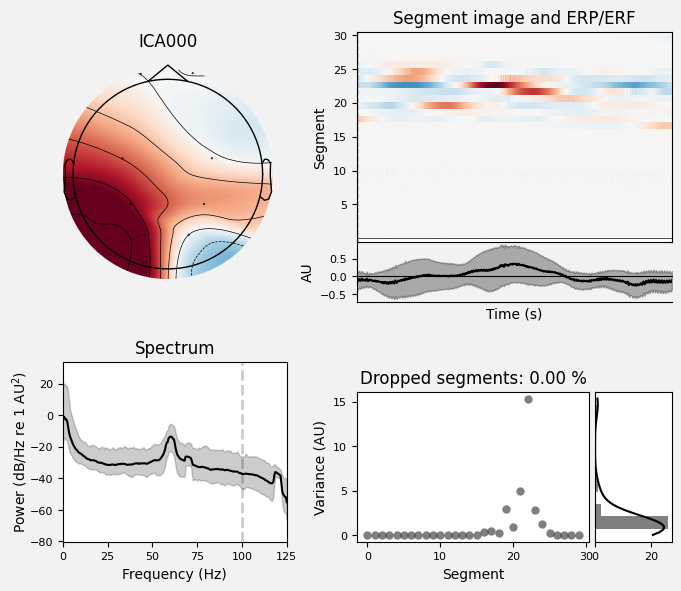

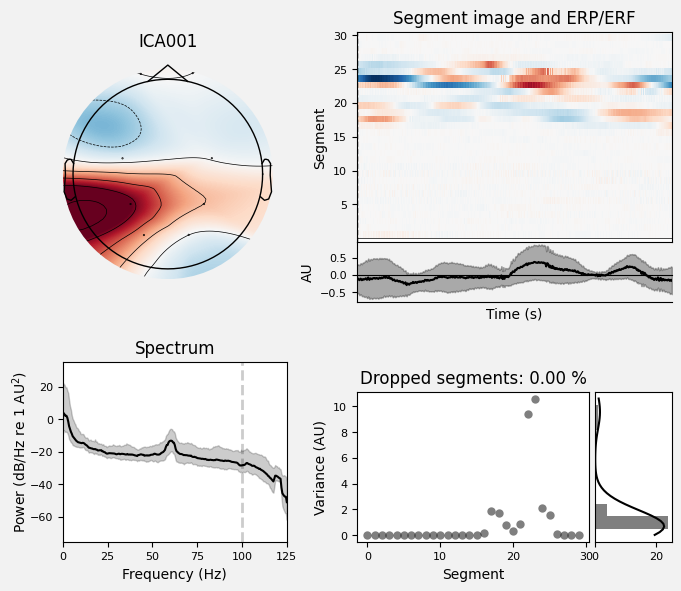

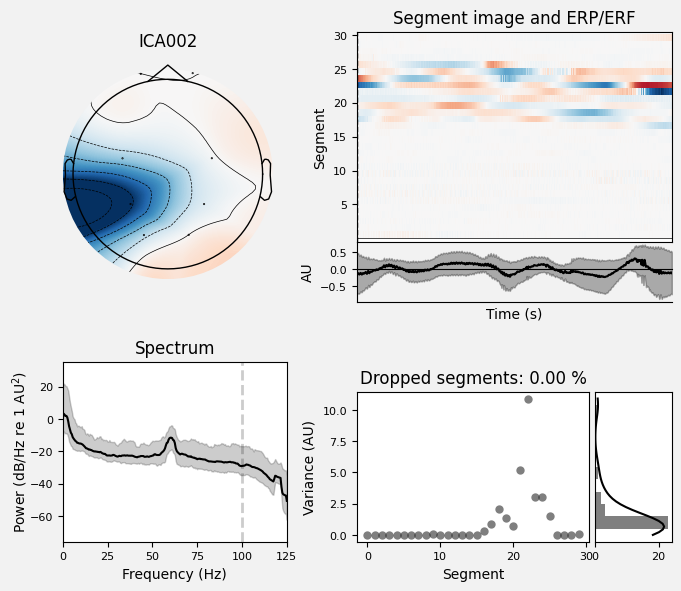

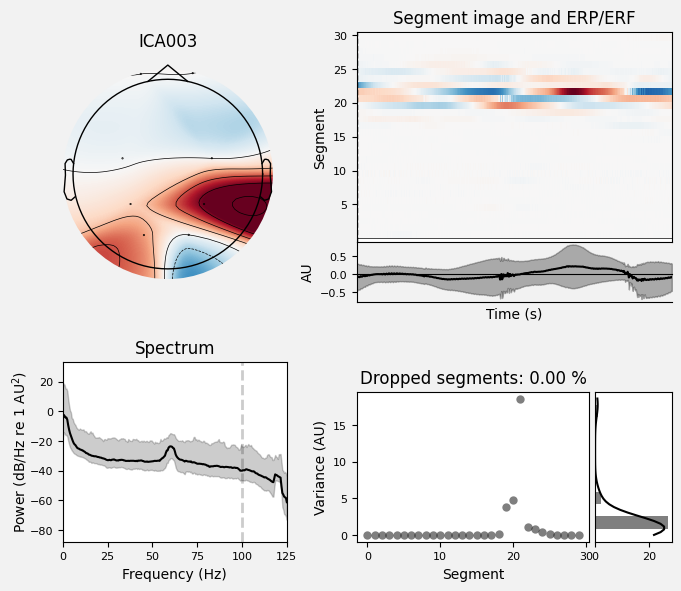

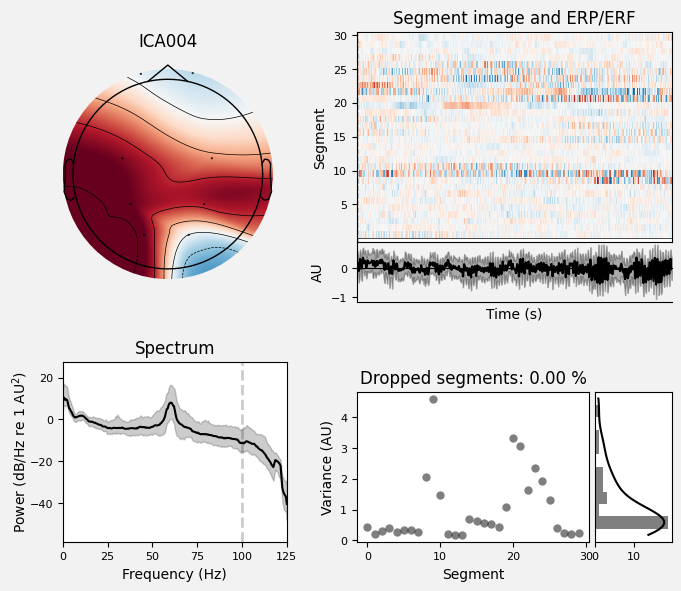

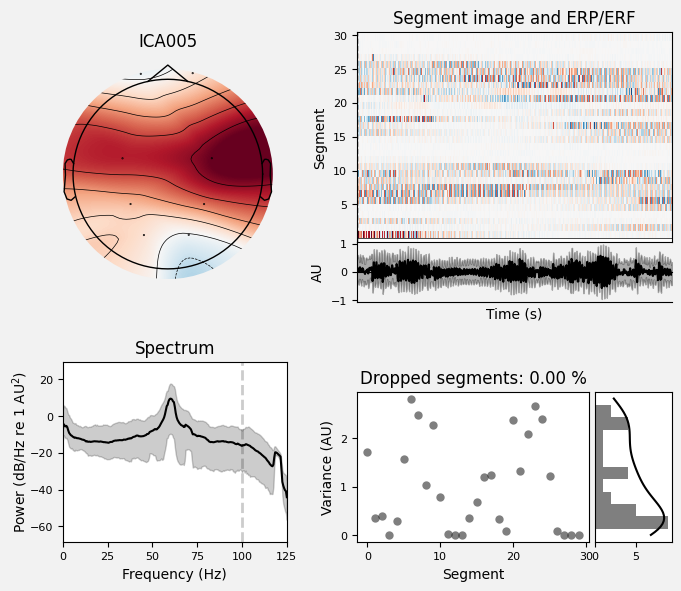

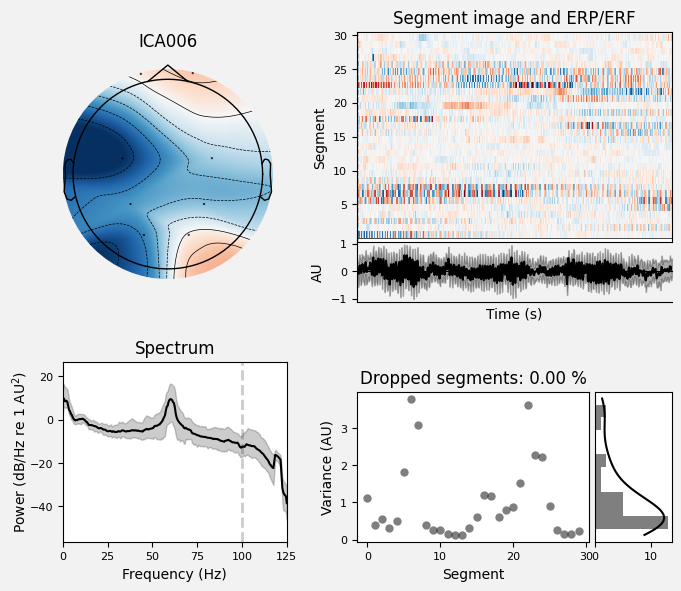

[<Figure size 700x600 with 6 Axes>,
 <Figure size 700x600 with 6 Axes>,
 <Figure size 700x600 with 6 Axes>,
 <Figure size 700x600 with 6 Axes>,
 <Figure size 700x600 with 6 Axes>,
 <Figure size 700x600 with 6 Axes>,
 <Figure size 700x600 with 6 Axes>]

In [1]:
import pandas as pd
import numpy as np
import mne

# =========================================================
# 1. Leer el archivo OpenBCI
# =========================================================
df = pd.read_csv(
    "Ultracortex.txt",
    comment="%",    # Ignora líneas de encabezado de OpenBCI
    header=0,
    sep=","
)

# Limpiar espacios en los nombres de columnas
df.rename(columns=lambda x: x.strip(), inplace=True)

# Seleccionar solo las columnas EEG (EXG)
eeg_cols = [f"EXG Channel {i}" for i in range(8)]
eeg_df = df[eeg_cols]

# =========================================================
# 2. Convertir de µV a V (lo que MNE espera)
# =========================================================
data_uV = eeg_df.to_numpy().T          # (n_canales, n_muestras) en µV
data = data_uV * 1e-6                  # Convertir de µV a V (lo que espera MNE)

sfreq = 250.0   # Según el txt: %Sample Rate = 250 Hz

# Nombres de los canales y tipo (EEG)
ch_names = [f"EEG{i+1}" for i in range(data.shape[0])]
ch_types = ["eeg"] * len(ch_names)

info = mne.create_info(ch_names=ch_names, sfreq=sfreq, ch_types=ch_types)
raw = mne.io.RawArray(data, info)

# =========================================================
# 3. Renombrar los canales a la convención estándar y aplicar montaje 10-20
# =========================================================
rename_dict = {
    "EEG1": "Fp1",
    "EEG2": "Fp2",
    "EEG3": "C3",
    "EEG4": "C4",
    "EEG5": "P3",
    "EEG6": "P4",
    "EEG7": "O1",
    "EEG8": "O2"
}
raw.rename_channels(rename_dict)

montage = mne.channels.make_standard_montage("standard_1020")
raw.set_montage(montage, match_case=False)

# =========================================================
# 4. Preprocesado (filtrado, recorte y eliminación de ruido)
# =========================================================
raw.load_data()
raw.crop(tmin=1.0)                    # Eliminar el primer segundo si es necesario
raw.notch_filter(freqs=[60, 100])     # Eliminar ruido de 60 Hz (y sus armónicos)

# Filtrado para visualización, ya que para ICA solo filtras 1-100 Hz
plot_raw = raw.copy()
plot_raw.filter(l_freq=1.0, h_freq=40.0)  # Banda típica para visualizar EEG

# Visualización de la señal EEG en una ventana de 10 segundos
plot_raw.plot(
    start=0,
    duration=10,
    n_channels=8,
    scalings=dict(eeg=500e-6),  # 60 µV por división
    show_scrollbars=True,
    title="EEG OpenBCI (10 s, 1–40 Hz)"
)

# =========================================================
# 5. Preparación de datos para ICA (filtrado 1-100 Hz)
# =========================================================
raw_ica = raw.copy()
raw_ica.filter(l_freq=1.0, h_freq=100.0)  # Filtrado para ICA (0.1-100 Hz)
raw_ica.crop(tmax=60.0)  # Trabajar solo con los primeros 60 segundos

# =========================================================
# 6. Ejecución de ICA con 7 componentes
# =========================================================
ica = mne.preprocessing.ICA(
    n_components=7,  # Elegir 7 componentes (puedes ajustar según visualización)
    method="fastica",  # Método ICA
    random_state=97  # Semilla para reproducibilidad
)
ica.fit(raw_ica)

# =========================================================
# 7. Visualización de los componentes ICA
# =========================================================
# Mapas topográficos de los componentes ICA
ica.plot_components()

# Visualización de las fuentes ICA en el tiempo
ica.plot_sources(raw_ica, start=1.0, stop=8.0)

# Visualización detallada de todos los componentes
ica.plot_properties(
    raw_ica,
    picks=[0, 1, 2, 3, 4, 5, 6],  # Inspección de todos los componentes
    psd_args=dict(fmax=125)   # Mostrar hasta 125 Hz (la mitad de Fs = 250 Hz)
)


Applying ICA to Raw instance
    Transforming to ICA space (7 components)
    Zeroing out 2 ICA components
    Projecting back using 8 PCA components


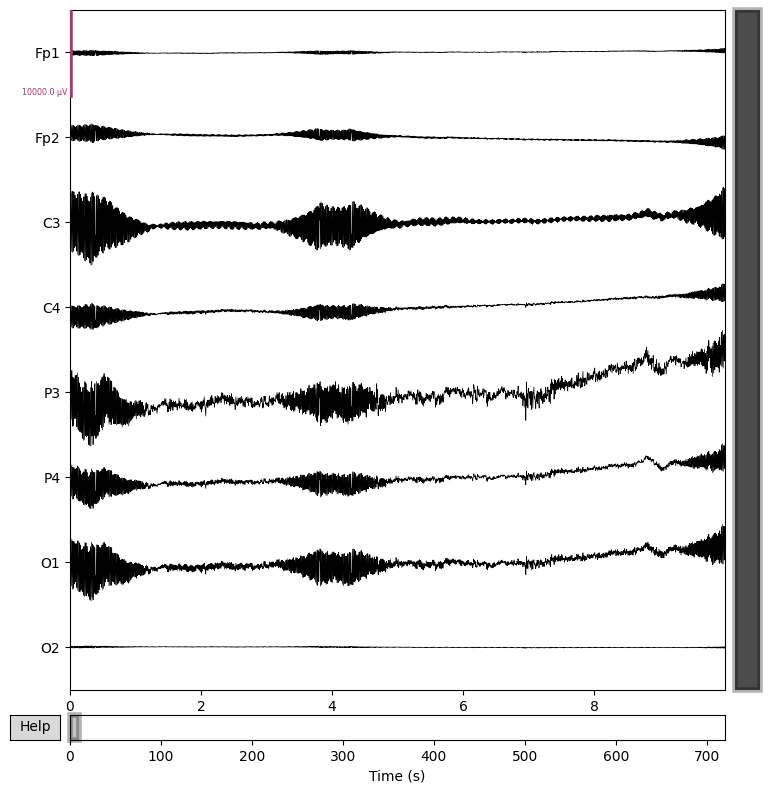

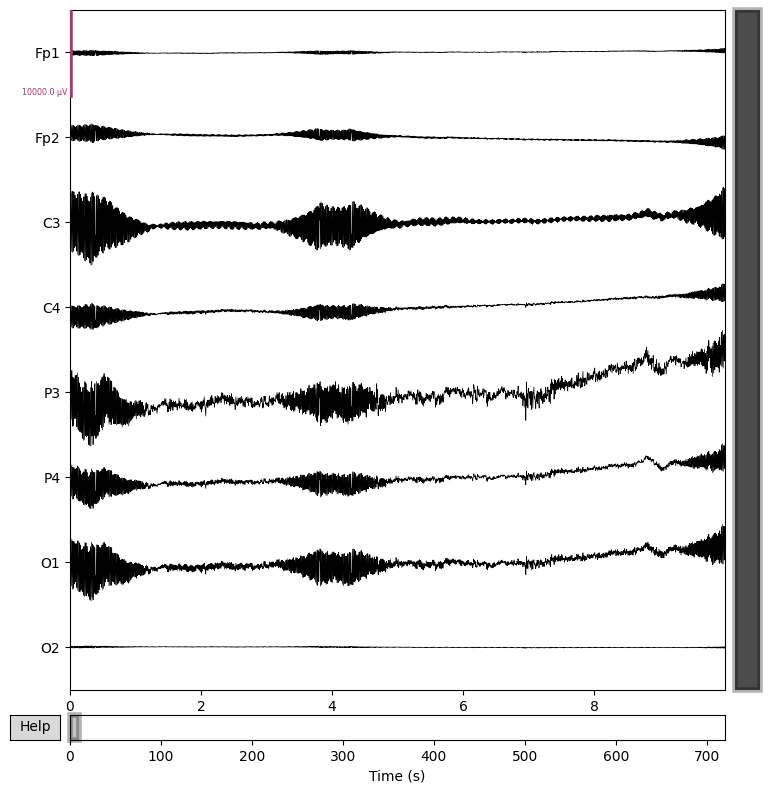

In [ ]:
# Después de hacer el ICA y visualizar los componentes...
# Eliminar los componentes ICA no deseados
ica.exclude = [1, 5]  # Excluir los componentes 0 y 1 (según lo identificado como artefactos)

# Aplicar ICA para eliminar esos componentes de la señal
raw_clean = ica.apply(raw.copy())

# Mostrar la señal después de la eliminación de los artefactos
raw_clean.plot(
    n_channels=8,
    duration=10,  # Duración de cada visualización
    scalings=dict(eeg=5000e-6),  # Escala ajustada para mejor visualización
    show_scrollbars=True,
    title="EEG limpio después de ICA (10 segundos)",
)

# Se eliminaron los componentes ICA 1 y 5 debido a que mostraron una forma de onda 
# que indicaba la presencia de ruido externo, posiblemente debido a artefactos como 
# interferencia electromagnética o ruido muscular. Estos componentes presentaron picos 
# atípicos o distorsiones en la señal que no correspondían a la actividad cerebral genuina.
#
# Después de eliminar estos componentes, la amplitud de la señal original pudo haberse 
# modificado, ya que esos componentes representaban variabilidad que no pertenecía 
# a la actividad cerebral de interés. La eliminación de estos artefactos hace que la señal 
# sea más representativa de la actividad neuronal real.
